Propagazione FULL PERTURBATIONS in corso per 30 giorni...

  MISSION ANALYSIS: VARIAZIONE PARAMETRI DOPO 30 GIORNI (SSO)
  Modello: Gravità 10x10, Atm Drag, SRP, Luni-Solar Third Body
1. SEMIASSE MAGGIORE (a)
   Iniziale: 7178.137 km
   Finale:   7174.315 km
   Delta:    -3821.52 metri (-3.821524 km) ((Decadimento Drag))
--------------------------------------------------------------------
2. ECCENTRICITÀ (e)
   Iniziale: 0.001000
   Finale:   0.001060
   Delta:    0.000060 (Oscillazione periodica J3/SRP/Terzo Corpo prevalente sull'effetto secolare del drag)
--------------------------------------------------------------------
3. INCLINAZIONE (i)
   Iniziale: 98.60000 deg
   Finale:   98.68065 deg
   Delta:    0.08065 deg (Micro-oscillazione)
--------------------------------------------------------------------
4. RAAN (Ω)
   Iniziale: 0.000 deg
   Finale:   29.640 deg (Standard Modulo 360)
             29.640 deg (Valore Reale Propagato)
   Delta:    29.640 deg (Drift reale normalizzato)

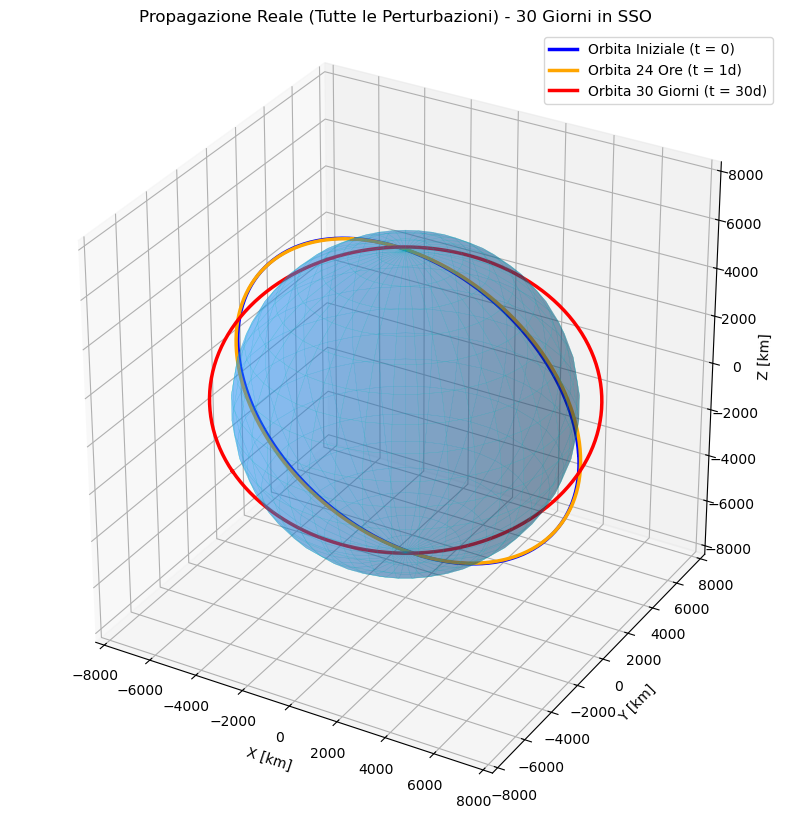

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState

from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

# ==========================================
# 2. DEFINIZIONE DEL TEMPO E DEI FRAME
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. CREAZIONE DELL'ORBITA (SSO a 800 km)
# ==========================================
h = 800e3
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + h
e = 0.001
i = math.radians(98.6)
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 850.0) # Massa 850 kg

# ==========================================
# 4. CONFIGURAZIONE DEL PROPAGATORE
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

ephemeris_generator = propagator.getEphemerisGenerator()

# ==========================================
# 5. AGGIUNTA DI TUTTE LE PERTURBAZIONI
# ==========================================
# Gravità EGM96 (Armoniche 10x10)
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# Third Body (Sole e Luna)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

# Atmosfera (Drag)
atmosphere = HarrisPriester(sun, earth_shape)
propagator.addForceModel(DragForce(atmosphere, IsotropicDrag(15.0, 2.2)))

# Pressione di Radiazione Solare (SRP)
propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(15.0, 1.8)))

# ==========================================
# 6. PROPAGAZIONE (30 GIORNI)
# ==========================================
giorni = 30.0
duration = giorni * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagazione FULL PERTURBATIONS in corso per {int(giorni)} giorni...")
final_state = propagator.propagate(final_date)

ephemeris = ephemeris_generator.getGeneratedEphemeris()
state_24h = ephemeris.propagate(initial_date.shiftedBy(24.0 * 3600.0))

orbit_24h = KeplerianOrbit(state_24h.getOrbit())
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 7. MISSION ANALYSIS REPORT
# ==========================================
# Estrazione parametri finali dimensionali
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())

# Estrazione valori grezzi (reali propagati, che possono essere negativi o > 360)
raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

# Valori standardizzati col modulo 360 per la notazione Kepleriana classica
raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0

# Calcolo del Delta fisico normalizzato (spostamento effettivo relativo allo zero, tra -180° e +180°)
delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: VARIAZIONE PARAMETRI DOPO {int(giorni)} GIORNI (SSO)")
print("  Modello: Gravità 10x10, Atm Drag, SRP, Luni-Solar Third Body")
print("====================================================================")
print(f"1. SEMIASSE MAGGIORE (a)")
print(f"   Iniziale: {a/1000:.3f} km")
print(f"   Finale:   {a_fin/1000:.3f} km")
print(f"   Delta:    {(a_fin - a):.2f} metri ({(a_fin - a)/1000:.6f} km) ((Decadimento Drag))")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITÀ (e)")
print(f"   Iniziale: {e:.6f}")
print(f"   Finale:   {e_fin:.6f}")
print(f"   Delta:    {e_fin - e:.6f} (Oscillazione periodica J3/SRP/Terzo Corpo prevalente sull'effetto secolare del drag)")
print("--------------------------------------------------------------------")
print(f"3. INCLINAZIONE (i)")
print(f"   Iniziale: {math.degrees(i):.5f} deg")
print(f"   Finale:   {i_fin:.5f} deg")
print(f"   Delta:    {i_fin - math.degrees(i):.5f} deg (Micro-oscillazione)")
print("--------------------------------------------------------------------")
print(f"4. RAAN (\u03A9)")
print(f"   Iniziale: {math.degrees(raan):.3f} deg")
print(f"   Finale:   {raan_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"             {raan_fin_raw:.3f} deg (Valore Reale Propagato)")
print(f"   Delta:    {delta_raan:.3f} deg (Drift reale normalizzato)")
print("--------------------------------------------------------------------")
print(f"5. ARGOMENTO DEL PERIGEO (\u03C9)")
print(f"   Iniziale: {math.degrees(omega):.3f} deg")
print(f"   Finale:   {omega_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"             {omega_fin_raw:.3f} deg (Valore Reale Propagato)")
print(f"   Delta:    {delta_omega:.3f} deg (Rotazione linea degli apsidi)")
print("====================================================================\n")

# ==========================================
# 8. VISUALIZZAZIONE 3D
# ==========================================
print("Generazione grafico 3D in corso...")
periodo_orbitale = 6050.0  

def estrai_orbita(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = estrai_orbita(0, periodo_orbitale)                                  
x1, y1, z1 = estrai_orbita(86400, 86400 + periodo_orbitale)                      
x30, y30, z30 = estrai_orbita(duration - periodo_orbitale, duration)             

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Orbita Iniziale (t = 0)')
ax.plot(x1, y1, z1, color='orange', linewidth=2.5, label='Orbita 24 Ore (t = 1d)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, label='Orbita 30 Giorni (t = 30d)')

lim = R_E_km + 2000
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Propagazione Reale (Tutte le Perturbazioni) - 30 Giorni in SSO')
ax.legend(loc='upper right')

plt.show()